## HEHE KITA MAIN DATA SEK

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('ggplot')
import random
import numpy as np

from warnings import filterwarnings
filterwarnings("ignore")

### CREATE USER DATA

In [2]:
users_data = []
number_users = 5000

for i in range(number_users):
    monthly_income = np.random.lognormal(mean=14, sigma=0.7)
    credit_score = np.random.normal(loc=0.6, scale=0.15)
    credit_score = np.clip(credit_score, 0, 1)
    
    users_data.append({
        "name": f"name-{i+1}",
        "age": random.randint(18, 45),
        "occupation": random.randint(0, 10),
        "monthly_income": int(monthly_income),
        "social_status": int(np.random.exponential(scale=1.2)),
        "location": random.randint(0, 5),
        "credit_score": credit_score,
    })

In [3]:
df = pd.DataFrame(users_data)
df

,name,age,occupation,monthly_income,social_status,location,credit_score
0,name-1,29,5,2211574,1,0,0.710178
1,name-2,38,6,1285073,0,0,0.678001
2,name-3,43,2,2839656,0,1,0.523419
3,name-4,28,3,1673278,3,4,0.554466
4,name-5,33,0,1550711,0,4,0.608860
...,...,...,...,...,...,...,...
4995,name-4996,37,8,1765876,0,3,0.296362
4996,name-4997,27,8,1002933,1,1,0.990487
4997,name-4998,31,9,1160143,1,2,0.713472
4998,name-4999,27,10,689643,0,1,0.677824


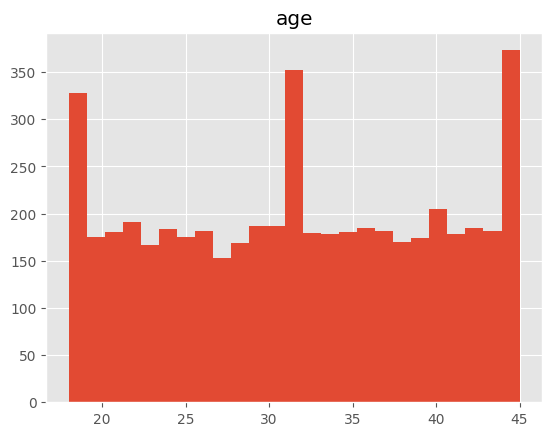

In [4]:
df.hist(column='age', bins=25)
plt.show()

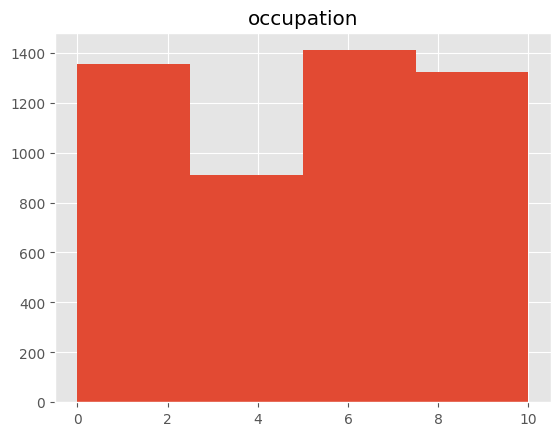

In [5]:
df.hist(column='occupation', bins=4)
plt.show()

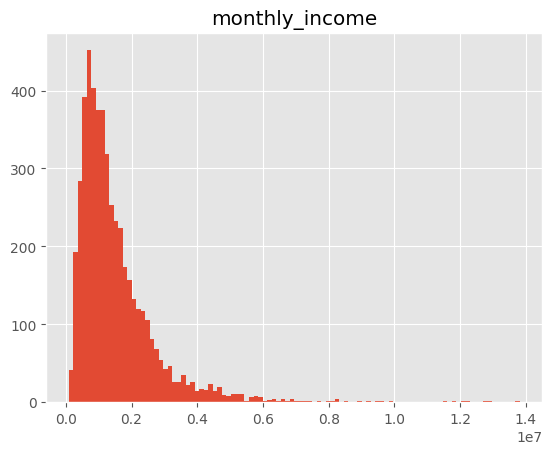

In [6]:
df.hist(column='monthly_income', bins=100)
plt.show()

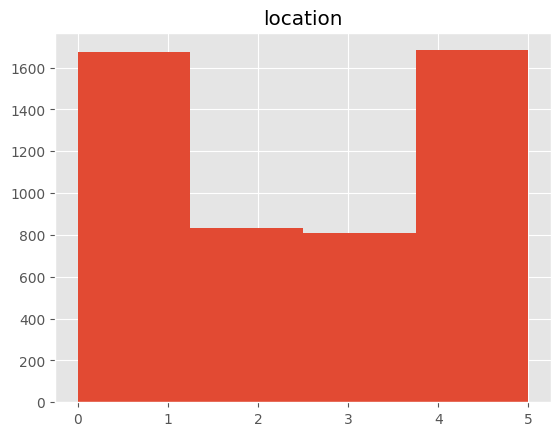

In [7]:
df.hist(column='location', bins=4)
plt.show()

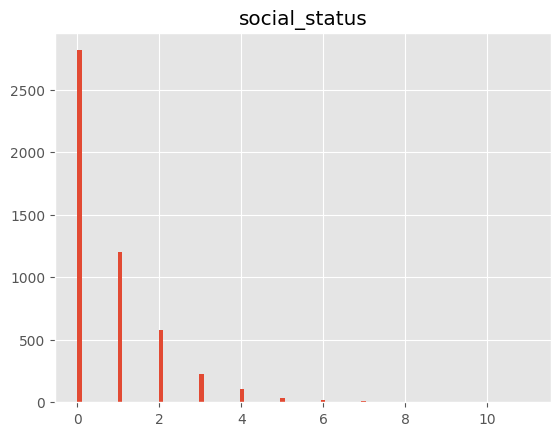

In [8]:
df.hist(column='social_status', bins=100)
plt.show()

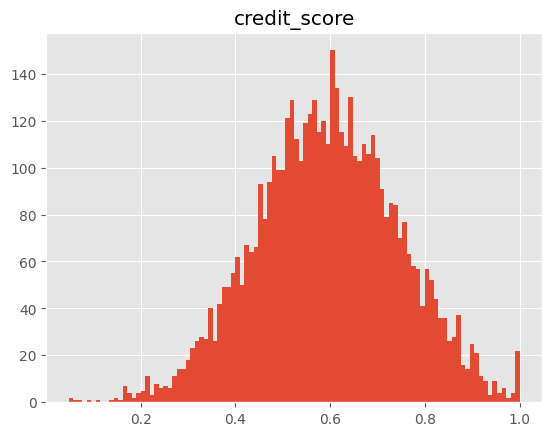

In [9]:
df.hist(column='credit_score', bins=100)
plt.show()

### CREATE USER HUB DATA BY HOW THEY RELATED EACH OTHER

In [10]:
user_hub = []
existing_relations = set()

for i in range(len(users_data)):
    for j in range(i + 1, len(users_data)):
        user_1 = users_data[i]
        user_2 = users_data[j]

        if abs(user_1['location'] - user_2['location']) < 2:

            if random.random() < 0.05:

                pair = tuple(sorted([user_1['name'], user_2['name']]))

                if pair not in existing_relations:
                    existing_relations.add(pair)

                    user_hub.append({
                        "user_1": pair[0],
                        "user_2": pair[1],
                        "related_kind": random.randint(1, 5)
                    })

In [11]:
pd.DataFrame(user_hub)

,user_1,user_2,related_kind
0,name-1,name-32,1
1,name-1,name-73,4
2,name-1,name-118,4
3,name-1,name-121,5
4,name-1,name-238,5
...,...,...,...
279398,name-4984,name-4989,5
279399,name-4985,name-5000,2
279400,name-4986,name-4999,2
279401,name-4988,name-4997,1


### CREATE USER ENGANGEMENT DATA BY HOW THE DO THEIR ACTIVITY

In [12]:
import random
import numpy as np
from collections import defaultdict
from datetime import datetime, timedelta

# -----------------------------------
# 1. Build adjacency map
# -----------------------------------
relation_map = defaultdict(dict)

for rel in user_hub:
    u1 = rel["user_1"]
    u2 = rel["user_2"]
    related_level = rel["related_kind"]
    
    relation_map[u1][u2] = related_level
    relation_map[u2][u1] = related_level


# -----------------------------------
# 2. Generate Activity Records
# -----------------------------------
activity_records = []

start_time = datetime.now()

for i in range(100):

    base_user = random.choice(users_data)["name"]
    participants = {base_user}

    if base_user in relation_map:
        for other_user, related_level in relation_map[base_user].items():

            join_prob = 0.05 + (related_level * 0.08)

            if random.random() < join_prob:
                participants.add(other_user)

    participants = list(participants)

    base_value = np.random.normal(loc=5_000_000, scale=2_000_000)

    value_creation = max(0, base_value * (1 + 0.3 * (len(participants) - 1)))

    activity_records.append({
        "user_names": participants,
        "activity": random.randint(0, 20),
        "value_creation": int(value_creation),
        "time_stamps": start_time + timedelta(minutes=i)
    })

In [13]:
activity_records_df = pd.DataFrame(activity_records)
activity_records_df

,user_names,activity,value_creation,time_stamps
0,"[name-3480, name-3311, name-4422, name-3613, n...",5,21180252,2026-02-25 01:02:49.263390
1,"[name-2413, name-1091, name-2390, name-2783, n...",14,64231344,2026-02-25 01:03:49.263390
2,"[name-4191, name-3901, name-2484, name-2275, n...",11,48392638,2026-02-25 01:04:49.263390
3,"[name-847, name-427, name-3242, name-4807, nam...",10,34737697,2026-02-25 01:05:49.263390
4,"[name-2187, name-2392, name-1316, name-1116, n...",10,48450674,2026-02-25 01:06:49.263390
...,...,...,...,...
95,"[name-267, name-738, name-2293, name-1160, nam...",0,48038078,2026-02-25 02:37:49.263390
96,"[name-2898, name-2528, name-2901, name-2685, n...",16,90618434,2026-02-25 02:38:49.263390
97,"[name-4995, name-4143, name-3452, name-125, na...",19,76212221,2026-02-25 02:39:49.263390
98,"[name-2455, name-3576, name-962, name-1667, na...",12,92641009,2026-02-25 02:40:49.263390


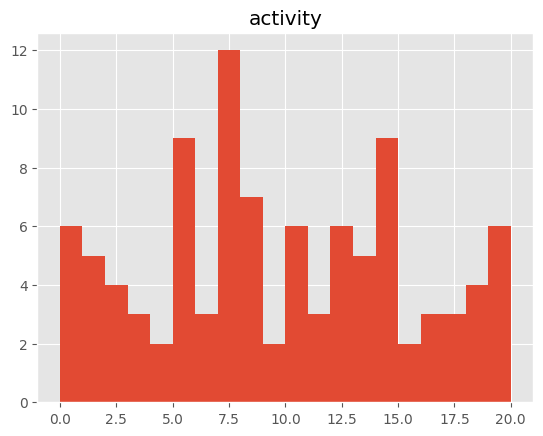

In [14]:
activity_records_df.hist(column='activity', bins=20)

plt.show()

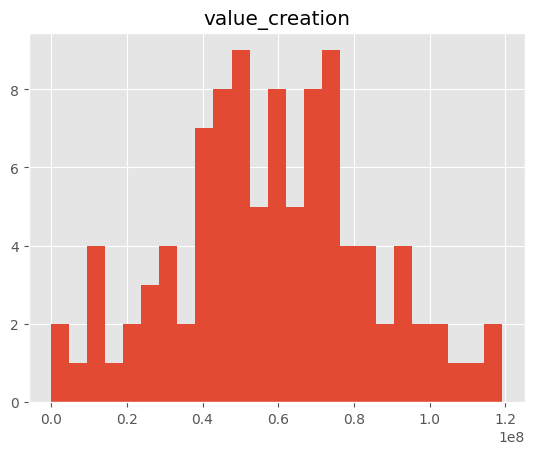

In [15]:
activity_records_df.hist(column='value_creation', bins=25)

plt.show()

### SAVE DATA

In [16]:
recorded_act = pd.DataFrame(activity_records)

recorded_act.to_csv("../datas/recorded-actifity.csv", index=False)

In [17]:
users_hub = pd.DataFrame(user_hub)

users_hub.to_csv("../datas/user-relation.csv", index=False)

In [18]:
users = pd.DataFrame(users_data)

users.to_csv("../datas/users.csv", index=False)

## Test Of using Data

In [19]:
actifity_data = pd.read_csv("../datas/recorded-actifity.csv")
user_data = pd.read_csv("../datas/users.csv")

### User Data

In [20]:
user_data

,name,age,occupation,monthly_income,social_status,location,credit_score
0,name-1,29,5,2211574,1,0,0.710178
1,name-2,38,6,1285073,0,0,0.678001
2,name-3,43,2,2839656,0,1,0.523419
3,name-4,28,3,1673278,3,4,0.554466
4,name-5,33,0,1550711,0,4,0.608860
...,...,...,...,...,...,...,...
4995,name-4996,37,8,1765876,0,3,0.296362
4996,name-4997,27,8,1002933,1,1,0.990487
4997,name-4998,31,9,1160143,1,2,0.713472
4998,name-4999,27,10,689643,0,1,0.677824


In [21]:
user_data_feature = user_data.drop(columns=['name', 'credit_score'], axis=1)
user_data_feature

,age,occupation,monthly_income,social_status,location
0,29,5,2211574,1,0
1,38,6,1285073,0,0
2,43,2,2839656,0,1
3,28,3,1673278,3,4
4,33,0,1550711,0,4
...,...,...,...,...,...
4995,37,8,1765876,0,3
4996,27,8,1002933,1,1
4997,31,9,1160143,1,2
4998,27,10,689643,0,1


In [22]:
print(f"max value of age is {user_data_feature['age'].max()} and min value of age is {user_data_feature['age'].min()}")

max value of age is 45 and min value of age is 18


In [23]:
print(f"max value of monthly income is {user_data_feature['monthly_income'].max()} and min value of monthly income is {user_data_feature['monthly_income'].min()}")

max value of monthly income is 13806489 and min value of monthly income is 86113


In [24]:
print(f"max value of occupation is {user_data_feature['occupation'].max()} and min value of occupation is {user_data_feature['occupation'].min()}")

max value of occupation is 10 and min value of occupation is 0


In [25]:
print(f"max value of social_status is {user_data_feature['social_status'].max()} and min value of social_status is {user_data_feature['social_status'].min()}")

max value of social_status is 11 and min value of social_status is 0


In [26]:
print(f"max value of location is {user_data_feature['location'].max()} and min value of location is {user_data_feature['location'].min()}")

max value of location is 5 and min value of location is 0


In [27]:
user_data_feature.shape

(5000, 5)

### Activity Data

In [28]:
actifity_data.head()

,user_names,activity,value_creation,time_stamps
0,"['name-3480', 'name-3311', 'name-4422', 'name-...",5,21180252,2026-02-25 01:02:49.263390
1,"['name-2413', 'name-1091', 'name-2390', 'name-...",14,64231344,2026-02-25 01:03:49.263390
2,"['name-4191', 'name-3901', 'name-2484', 'name-...",11,48392638,2026-02-25 01:04:49.263390
3,"['name-847', 'name-427', 'name-3242', 'name-48...",10,34737697,2026-02-25 01:05:49.263390
4,"['name-2187', 'name-2392', 'name-1316', 'name-...",10,48450674,2026-02-25 01:06:49.263390


In [29]:
print(f"max value of value_creation is {actifity_data['value_creation'].max()} and min value of value_creation is {actifity_data['value_creation'].min()}")

max value of value_creation is 119140655 and min value of value_creation is 0


In [30]:
print(f"max value of activity is {actifity_data['activity'].max()} and min value of activity is {actifity_data['activity'].min()}")

max value of activity is 20 and min value of activity is 0


In [31]:
adjency_dictionary = {
    "idx": [i for i in user_data['name'].to_list()]
}

for i in user_data['name']:
    adjency_dictionary[i] = [0] * len(user_data['name'].to_list())

In [32]:
adjency_dictionary_dataframe = pd.DataFrame(adjency_dictionary)

adjency_dictionary_dataframe.set_index("idx", inplace=True)

adjency_dictionary_dataframe.columns

Index(['name-1', 'name-2', 'name-3', 'name-4', 'name-5', 'name-6', 'name-7',
       'name-8', 'name-9', 'name-10',
       ...
       'name-4991', 'name-4992', 'name-4993', 'name-4994', 'name-4995',
       'name-4996', 'name-4997', 'name-4998', 'name-4999', 'name-5000'],
      dtype='object', length=5000)

In [33]:
from tqdm.notebook import tqdm

In [34]:
import ast

max_value_creation_ever_recorded = 116612972
min_value_creation_ever_recorded = 4540178

for names, value_creation, act in tqdm(zip(
    actifity_data['user_names'],
    actifity_data['value_creation'],
    actifity_data['activity']
), total=len(actifity_data['user_names'].to_list()), desc="processing the data.."):
    names_as_litearal_list = ast.literal_eval(names)
    normalize_value_creation = (value_creation - min_value_creation_ever_recorded) / max_value_creation_ever_recorded
    normalize_actifity = act / 20
    adjency_vertice_score = (normalize_value_creation * 10 + normalize_actifity * 8) / 18
    
    for i in range(len(names_as_litearal_list)):
        for j in range(i+1, len(names_as_litearal_list) - 1 - i):
            name1 = names_as_litearal_list[i]
            name2 = names_as_litearal_list[j]
            adjency_dictionary_dataframe.loc[name1, name2] += adjency_vertice_score
            adjency_dictionary_dataframe.loc[name2, name1] += adjency_vertice_score

processing the data..:   0%|          | 0/100 [00:00<?, ?it/s]

In [35]:
adjency_dictionary_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, name-1 to name-5000
Columns: 5000 entries, name-1 to name-5000
dtypes: float64(2417), int64(2583)
memory usage: 190.9+ MB


In [36]:
adjency_dictionary_matrix = adjency_dictionary_dataframe.to_numpy()

In [39]:
adjency_dictionary_matrix.shape

(5000, 5000)

In [38]:
adjency_dictionary_matrix.max()

np.float64(1.5403232143561754)

## Data Tabulation

In [ ]:
class DataTabulate:
    def __init__(self):
        self.__nodes = None
        self.__adjency_matrix = None

## MODEL DEVELOPMENT

In [ ]:
import numpy as np

class GCN_CREDIT_SCORING_AWARNESS:
    def __init__(self):
        self.__key_paring_activating = {
            "relu": {0: self.__relu_backward, 1: self.__relu_forward},
            "sigmoid": {0: self.__sigmoid_backward, 1: self.__sigmoid_forward},
        }
        
        self.__W = None
        self.__B = None

    def __relu_forward(self, x):
        return np.maximum(0, x)

    def __relu_backward(self, dA, x):
        dZ = np.array(dA, copy=True)
        dZ[x <= 0] = 0
        return dZ

    def __sigmoid_forward(self, x):
        return 1 / (1 + np.exp(-x))

    def __sigmoid_backward(self, dA, x):
        s = 1 / (1 + np.exp(-x))
        dZ = dA * s * (1 - s)
        return dZ

    def __softmax(self, x):
        e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
        return e_x / e_x.sum(axis=-1, keepdims=True)